# 🏦 Bank Customer Churn Prediction

## 📌 Problem Statement
Customer churn is one of the most costly challenges in banking. When a customer exits, the bank loses not just their deposits but the lifetime revenue they represent. This notebook builds a **complete end-to-end ML pipeline** — from raw data to a deployed model — to predict which customers are at risk of churning, enabling proactive retention.

## 🎯 Objective
- Identify behavioral and demographic patterns that distinguish churners from loyal customers
- Build and compare multiple classification models with proper class-imbalance handling
- Select the best model and evaluate it rigorously with business-relevant metrics

## 📂 Dataset
- **Source:** [Bank Customer Churn — Kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction)
- **Records:** 10,000 customers | **Features:** 14 | **Target:**  (1 = Churned, 0 = Stayed)

## 🗂️ Pipeline Overview


| Stage | Details |
|---|---|
| EDA | Demographics, financials, behavioral patterns |
| Imbalance Handling | SMOTE oversampling on training data only |
| Models Compared | 9 classifiers including XGBoost, Random Forest, Gradient Boosting |
| Final Model | Gradient Boosting Classifier |
| Key Metrics | F1 Score, AUC-ROC, Recall, Confusion Matrix |


## 1. 📥 Data Loading & Libraries
Importing all necessary libraries and loading the dataset. Dropping identifier columns (, , ) which carry no predictive value.

In [61]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, accuracy_score, recall_score,
                              precision_score, f1_score, confusion_matrix,
                              roc_auc_score, roc_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
import pickle, json as _json

warnings.filterwarnings("ignore")

In [62]:
warnings.filterwarnings("ignore")
df =  pd.read_csv("../data/Churn_Modelling.csv")

df  = df.iloc[:,3:]

## 2. 🔍 Data Quality Check
Checking for **missing values** and **duplicate rows** before analysis. Clean data is the foundation of reliable insights.

In [63]:
duplicate_count = df.duplicated().sum()

print(f"DUPLICATE ROWS : {duplicate_count}")


# Null Report
null_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing (%)":   df.isnull().mean().mul(100).round(2)
})

null_report = null_report[null_report["Missing Count"] > 0]

print(null_report if not null_report.empty else "No missing values")

DUPLICATE ROWS : 0
No missing values


## 3. 📊 Churn Distribution
Understanding class balance before modeling. With ~20% churn, the dataset is moderately imbalanced — we will address this with SMOTE during training.


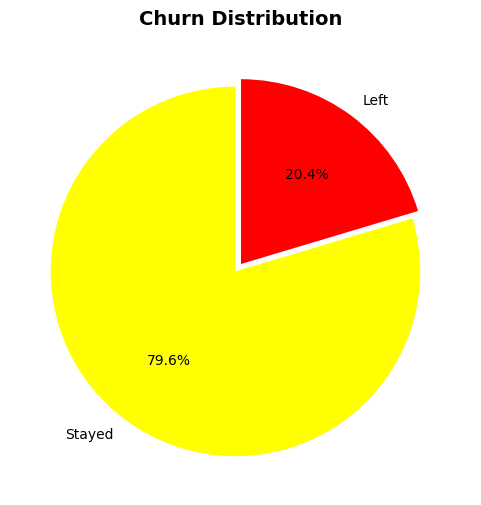

In [64]:
x = df["Exited"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(x, 
        labels=["Stayed", "Left"], 
        autopct="%1.1f%%",
       colors=["yellow","red"],
        explode=(0.05, 0),
        startangle=90,
        )

plt.title("Churn Distribution", fontsize=14, fontweight="bold")
plt.show()



## 4. 👥 Gender Analysis
Comparing churn rates across genders using a normalized crosstab heatmap.

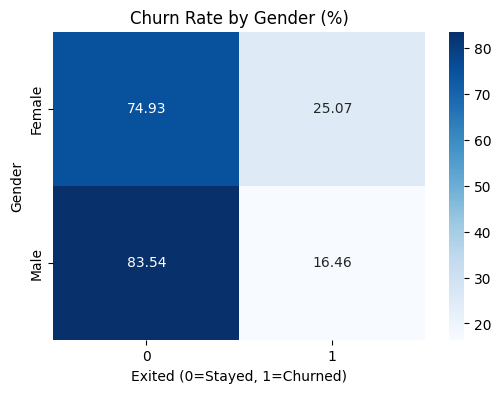

In [65]:


# Create crosstab
ct = round(pd.crosstab(df["Gender"], df["Exited"], normalize="index") * 100, 2)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Churn Rate by Gender (%)")
plt.xlabel("Exited (0=Stayed, 1=Churned)")
plt.ylabel("Gender")
plt.show()

## 5. 💳 Credit Score Analysis
Examining whether churned customers differ meaningfully in their credit profiles. Credit score is a common proxy for financial stability.


In [66]:
print(df.groupby("Exited")["CreditScore"].mean())

Exited
0    651.853196
1    645.351497
Name: CreditScore, dtype: float64


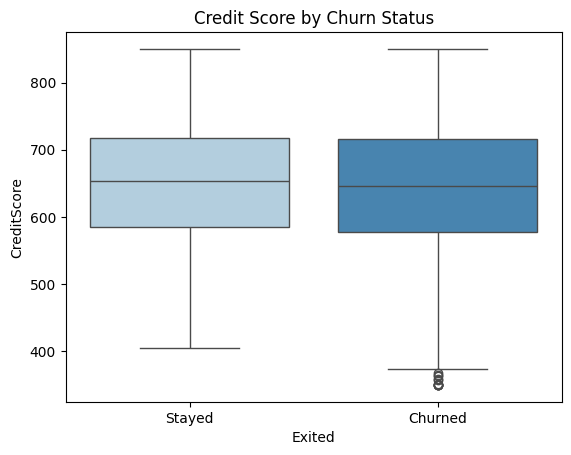

In [67]:
sns.boxplot(data=df, x="Exited", y="CreditScore", palette="Blues")
plt.title("Credit Score by Churn Status")
plt.xticks([0,1], ["Stayed", "Churned"])
plt.show()


In [68]:
cols = ["CreditScore", "Age", "Balance", "EstimatedSalary", "Tenure"]

for col in cols:
      churned_skew = round(df[df["Exited"] == 1][col].skew(), 2)
      stayed_skew  = round(df[df["Exited"] == 0][col].skew(), 2)
      print(f"{col:20} | Churned: {churned_skew:6} | Stayed: {stayed_skew:6}")


CreditScore          | Churned:  -0.14 | Stayed:  -0.05
Age                  | Churned:   0.08 | Stayed:   1.38
Balance              | Churned:  -0.51 | Stayed:  -0.05
EstimatedSalary      | Churned:  -0.03 | Stayed:   0.01
Tenure               | Churned:   0.05 | Stayed:    0.0


## 6. 🎂 Age Analysis
Age is one of the strongest churn predictors in this dataset. Older customers tend to have established relationships with other banks, making them more likely to switch.

> **Hypothesis:** Customers aged 40+ represent the highest churn risk.


In [69]:
round(df.groupby("Exited")["Age"].agg(["mean",  "std", "skew"]),2)   

,mean,std,skew
Exited,,,
0,37.41,10.13,1.38
1,44.84,9.76,0.08


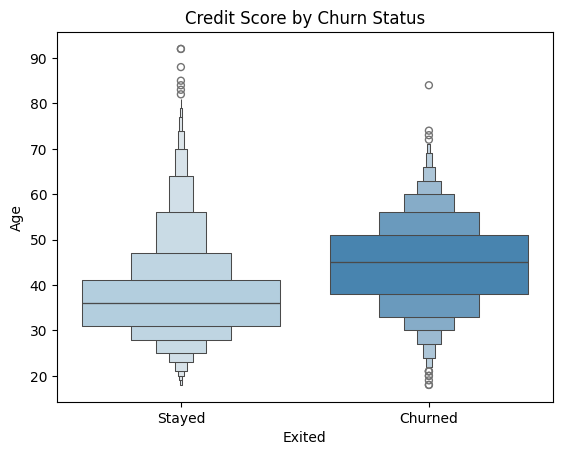

In [70]:
sns.boxenplot(data=df,x="Exited",y="Age",palette="Blues")
plt.title("Credit Score by Churn Status")
plt.xticks([0,1], ["Stayed", "Churned"])
plt.show()


### 📌 Insight
- **Age** is the single strongest churn predictor: churned customers average ~45 years vs ~37 for retained
- **Balance:** Counter-intuitively, churned customers hold *higher* average balances — high-value attrition
- **Tenure:** Nearly identical distributions — tenure alone does not predict churn


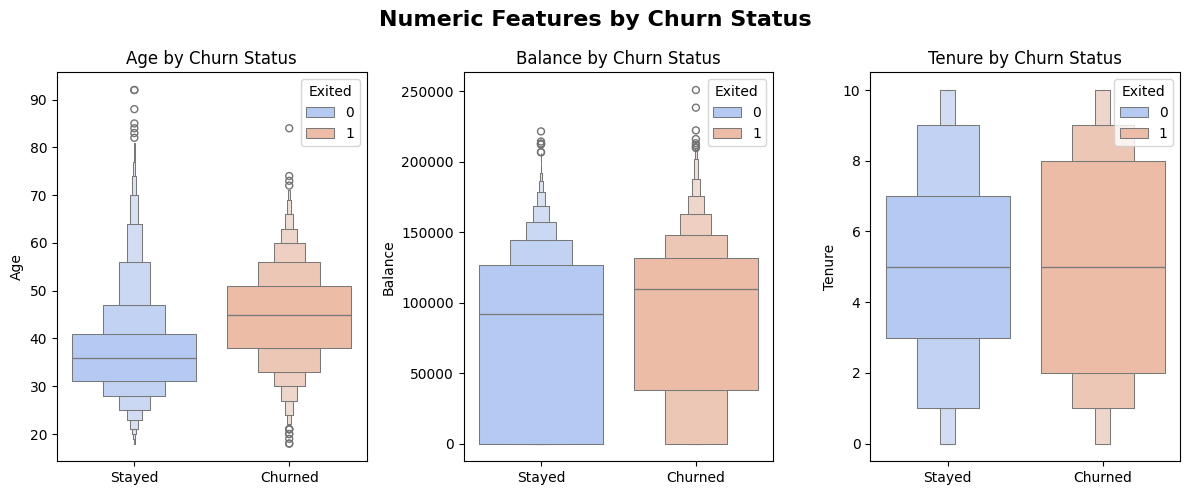

In [71]:
cols = ["Age", "Balance", "Tenure"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxenplot(data=df, x="Exited", y=col, palette="coolwarm",hue="Exited", ax=axes[i])
    axes[i].set_title(f"{col} by Churn Status")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Stayed", "Churned"])
    axes[i].set_xlabel("")

plt.suptitle("Numeric Features by Churn Status", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.1 📅 Churn Rate by Tenure Year
New customers (0–1 years) show the highest early churn risk — they have not yet built loyalty with the bank.

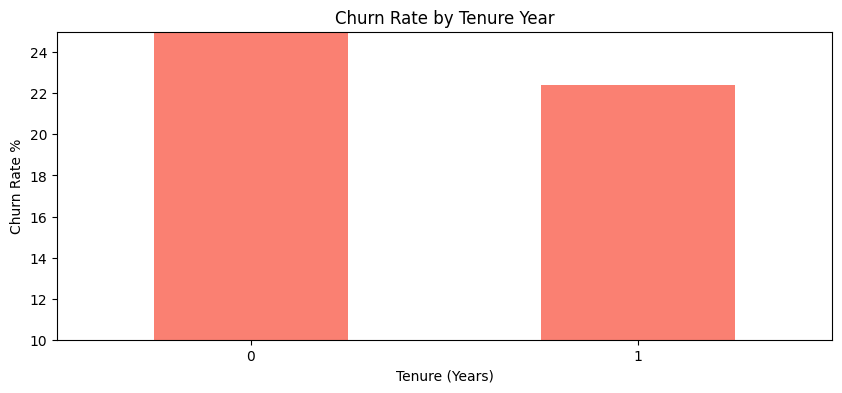

In [72]:
ct = pd.crosstab( df["Exited"], df["Tenure"],normalize="columns") * 100
ct[1].plot(kind="bar", figsize=(10,4), color="salmon")
plt.title("Churn Rate by Tenure Year")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate %")
plt.ylim(10,25)
plt.xticks(rotation=0)
plt.show()  

## 7. ✅ Active Membership & Credit Card
**IsActiveMember** is a high-signal behavioral feature. An inactive member is passively disengaged — a strong early warning of churn.


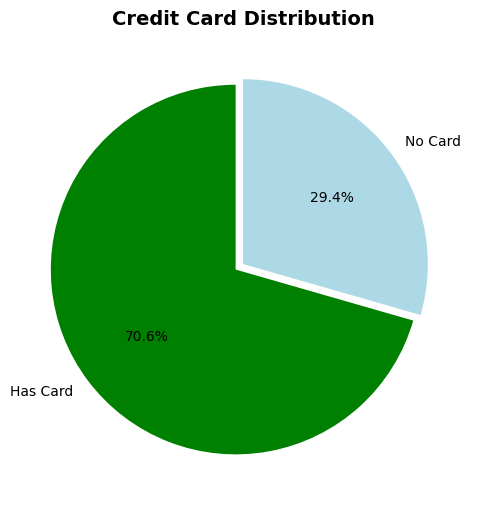

In [73]:


x = df["HasCrCard"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(x, 
        labels=["Has Card", "No Card"], 
        autopct="%1.1f%%",
        colors=["green","lightblue"],
        explode=(0.05, 0),
        startangle=90,
       )

plt.title("Credit Card Distribution", fontsize=14, fontweight="bold")
plt.show()


In [74]:
round(pd.crosstab(df["Exited"],df["HasCrCard"],normalize="columns")*100,2)

HasCrCard,0,1
Exited,,
0,79.19,79.82
1,20.81,20.18


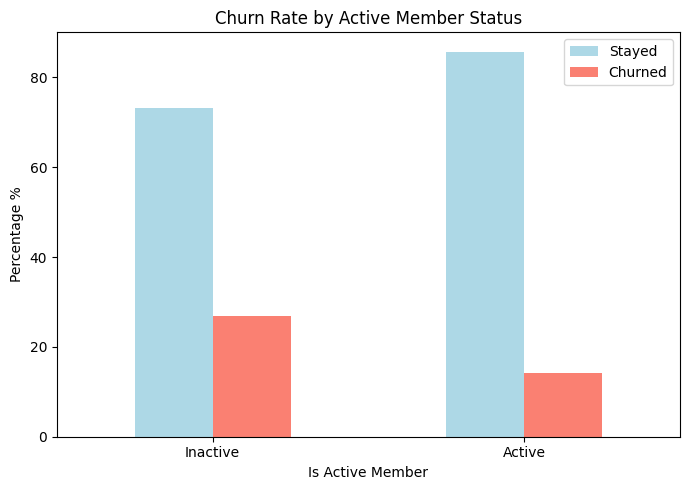

In [75]:
ct = round(pd.crosstab(df["Exited"], df["IsActiveMember"], normalize="columns") * 100, 2)

ct.T.plot(kind="bar", figsize=(7,5), color=["lightblue","salmon"])
plt.title("Churn Rate by Active Member Status")
plt.xlabel("Is Active Member")
plt.xticks([0,1], ["Inactive","Active"], rotation=0)
plt.ylabel("Percentage %")
plt.legend(["Stayed","Churned"])
plt.tight_layout()
plt.show()

### 📌 Insight
Inactive members churn at nearly **2× the rate** of active members. This is one of the most actionable findings for retention campaigns.

## 8. 💰 Financial Metrics by Gender & Churn
Breaking down average balance and salary by gender and churn status to identify whether financial differences are gender-driven or churn-driven.

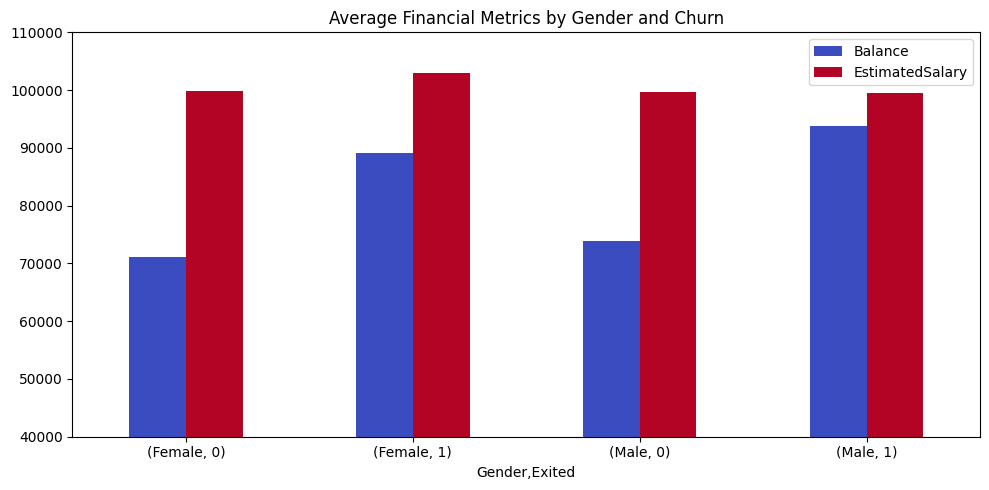

In [76]:
df.groupby(["Gender","Exited"])[["Balance","EstimatedSalary"]].mean().round(2).plot(
    kind="bar", figsize=(10,5), colormap="coolwarm")
plt.title("Average Financial Metrics by Gender and Churn")
plt.xticks(rotation=0)
plt.ylim(40000,110000)
plt.tight_layout()
plt.show()

## 9. 🌍 Geography Analysis
Customer location reflects different banking cultures and competitive environments. Germany stands out as a significant churn hotspot.


In [77]:
df.pivot_table(values=["Balance","CreditScore","Age","EstimatedSalary"],
               index="Geography",
               columns="Exited",
               aggfunc="mean").round(2)

Age           Balance            CreditScore          \
Exited         0      1          0          1           0       1   
Geography                                                           
France     37.24  45.13   60339.28   71192.80      651.16  641.91   
Germany    37.31  44.89  119427.11  120361.08      653.26  647.69   
Spain      37.84  44.15   59678.07   72513.35      652.10  647.48   

          EstimatedSalary             
Exited                  0          1  
Geography                             
France           99217.10  103439.28  
Germany         102414.66   98403.89  
Spain            98602.37  103629.55

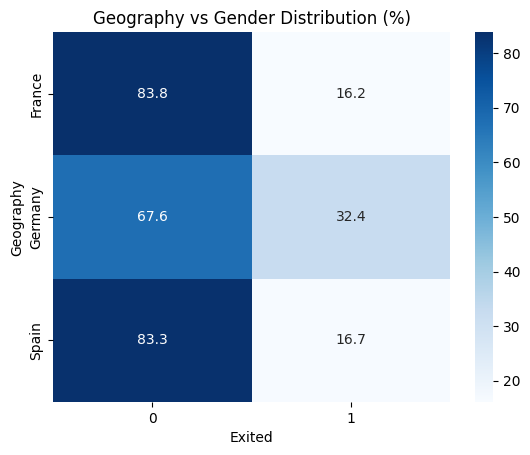

In [78]:
ct = pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100

sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Geography vs Gender Distribution (%)")
plt.show()

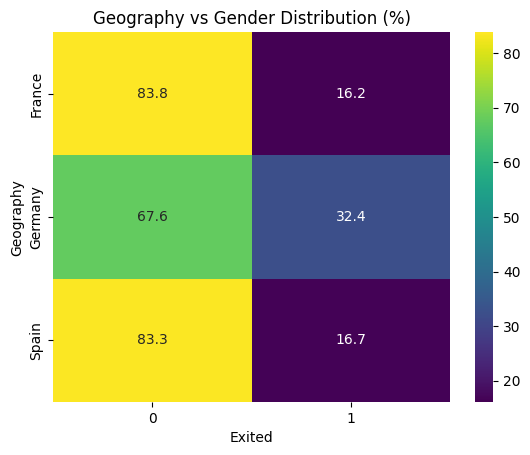

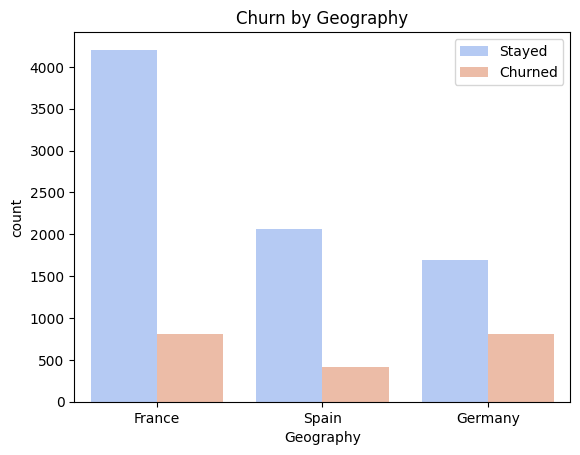

In [79]:

ct = pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100

sns.heatmap(ct, annot=True, fmt=".1f", cmap="viridis")
plt.title("Geography vs Gender Distribution (%)")
plt.show()

sns.countplot(data=df, x="Geography", hue="Exited", palette="coolwarm")
plt.title("Churn by Geography")
plt.xticks(rotation=0)
plt.legend(["Stayed","Churned"])
plt.show()

### 📌 Insight
Germany has a churn rate of ~**32%** — nearly double France and Spain (~16%). A dedicated Germany-specific retention strategy is warranted.

## 10. 📦 Number of Products
The number of products held reflects relationship depth. More products typically means higher switching costs — but the data reveals a surprising non-linear pattern.


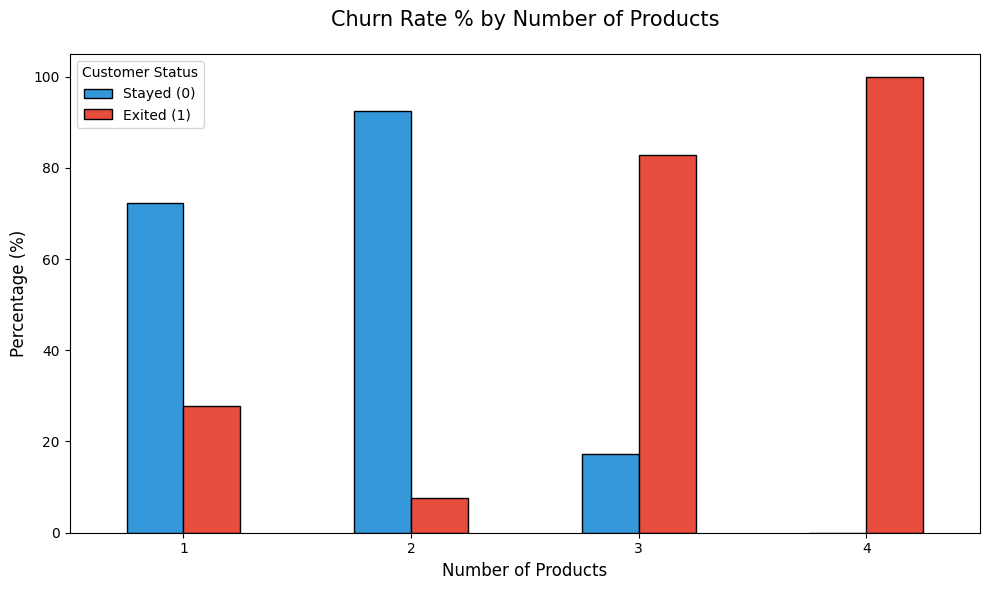

In [80]:
ct  = round(pd.crosstab(df["Exited"],df["NumOfProducts"],normalize="columns")*100,2)

# Assuming 'ct' is your crosstab result
ax = ct.T.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c'], edgecolor='black')

# 3. Add titles and labels
plt.title('Churn Rate % by Number of Products', fontsize=15, pad=20)
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Customer Status', labels=['Stayed (0)', 'Exited (1)'])
plt.xticks(rotation=0)  # Keeps the X-axis labels upright
plt.tight_layout()
plt.show()

### 📌 Key Finding
| Products | Churn Rate | Avg Balance |
|---|---|---|
| 1 | ~27% | Moderate |
| 2 | ~7.6% | 1,879 (most loyal) |
| 3 | ~82% | High |
| 4 | **100%** | 3,733 |

The **2-product sweet spot** is the bank's most loyal segment. Cross-selling beyond 2 products paradoxically destroys loyalty.


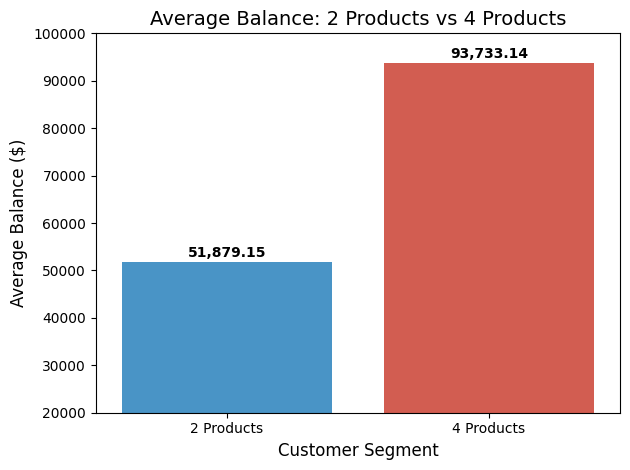

In [81]:
a = df[df["NumOfProducts"] == 2]["Balance"].mean()
b = df[df["NumOfProducts"] == 4]["Balance"].mean()

# 2. Create the bar plot
# We define x as labels and y as the calculated values
sns.barplot(x=['2 Products', '4 Products'], y=[a, b], palette=['#3498db', '#e74c3c'])

# 3. Add titles and labels
plt.title('Average Balance: 2 Products vs 4 Products', fontsize=14)
plt.ylabel('Average Balance ($)', fontsize=12)
plt.xlabel('Customer Segment', fontsize=12)
plt.text(0, a + 1000, f'{a:,.2f}', ha='center', fontweight='bold')
plt.text(1, b + 1000, f'{b:,.2f}', ha='center', fontweight='bold')
plt.ylim(20000,100000)
plt.tight_layout()
plt.show()

## 11. 📋 EDA Summary — Top Churn Drivers

| Feature | Direction | Strength |
|---|---|---|
| Age | Older → Higher churn | ⭐⭐⭐⭐⭐ |
| IsActiveMember | Inactive → Higher churn | ⭐⭐⭐⭐⭐ |
| Geography (Germany) | Germany → ~32% churn | ⭐⭐⭐⭐ |
| NumOfProducts | 4 products → 100% churn | ⭐⭐⭐⭐ |
| Balance | Higher balance → Higher churn | ⭐⭐⭐ |
| Tenure (0–1 yr) | New customers → Higher early churn | ⭐⭐⭐ |
| Gender | Slight female skew | ⭐⭐ |
| CreditScore / Salary | Minimal difference | ⭐ |

> These insights directly informed feature selection for the modeling phase below.


---
## 12. ⚙️ Feature Engineering & Preprocessing

Based on EDA, we select the most predictive features and apply:
- **StandardScaler** on numeric features (Age, Balance, CreditScore, EstimatedSalary, NumOfProducts, IsActiveMember)
- **OrdinalEncoder** on categorical features (Geography, Gender)
- **Stratified train/test split** (80/20) to preserve class ratios


In [82]:
df = pd.read_csv("../data/Churn_Modelling.csv")

df["Zero_Balance"]         = (df["Balance"] == 0).astype(int)
df["Balance_Salary_Ratio"] = df["Balance"] / (df["EstimatedSalary"] + 1)
df["Products_Bucket"]      = (df["NumOfProducts"] >= 3).astype(int)   # 2-vs-3+ cliff
df["Age_Inactive"]         = df["Age"] * (df["IsActiveMember"] == 0)  # older + inactive
df["Germany_HighBal"]      = ((df["Geography"] == "Germany") &
                               (df["Balance"] > df["Balance"].median())).astype(int)

num_features = ["Age", "Balance", "CreditScore", "EstimatedSalary",
                "NumOfProducts", "IsActiveMember",
                "Zero_Balance", "Balance_Salary_Ratio",
                "Products_Bucket", "Age_Inactive", "Germany_HighBal"]
cat_features = ["Geography", "Gender"]

X = df[num_features + cat_features]
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OrdinalEncoder(), cat_features)
])

print(X_train.shape, X_test.shape)

(8000, 13) (2000, 13)


## 13. 🤖 Model Comparison — 9 Classifiers

### Strategy
The dataset has a **~20% churn rate** (class imbalance). Optimizing for raw accuracy is misleading — a model predicting everyone stays gets 80% accuracy but is useless for retention.

**Solution applied:**
- **SMOTE** — Synthetic oversampling of minority class (churned) on training data only
- **class_weight='balanced'** — For sklearn models
- **scale_pos_weight** — For XGBoost
- **Primary metric: F1 Score** — Balances precision and recall, ideal for imbalanced classification

> SMOTE is applied inside the pipeline to prevent data leakage — test set is never touched during oversampling.


In [83]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = round(neg / pos, 2)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(random_state=42, class_weight="balanced"),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "AdaBoost":            AdaBoostClassifier(random_state=42),
    "Extra Trees":         ExtraTreesClassifier(random_state=42, class_weight="balanced"),
    "Ridge Classifier":    RidgeClassifier(class_weight="balanced"),
    "SGD Classifier":      SGDClassifier(random_state=42, class_weight="balanced"),
    "XGBoost":             XGBClassifier(scale_pos_weight=scale, eval_metric="logloss", random_state=42),
}

results = []
for name, model in models.items():
    pipe = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        "Model":     name,
        "F1":        round(f1_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
    })
    print(f"{name}: done")

pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)

Logistic Regression: done
Random Forest: done
Gradient Boosting: done
Decision Tree: done
AdaBoost: done
Extra Trees: done
Ridge Classifier: done
SGD Classifier: done
XGBoost: done


,Model,F1,Recall,Precision,Accuracy
0,Gradient Boosting,0.6263,0.7125,0.5588,0.8270
1,AdaBoost,0.5927,0.7150,0.5061,0.8000
2,Random Forest,0.5909,0.5872,0.5945,0.8345
3,Extra Trees,0.5882,0.5774,0.5995,0.8355
4,Ridge Classifier,0.5806,0.7297,0.4821,0.7855
5,Logistic Regression,0.5712,0.7248,0.4712,0.7785
6,SGD Classifier,0.5634,0.6929,0.4747,0.7815
7,XGBoost,0.5609,0.7297,0.4555,0.7675
8,Decision Tree,0.4935,0.5602,0.4410,0.7660


## 14. Final Model — XGBoost + Hyperparameter Tuning

XGBoost with SMOTETomek (cleans noisy synthetic samples at the decision boundary) and RandomizedSearchCV scoring on F1.

In [84]:
base = ImbPipeline([
    ("preprocessor", preprocessor),
    ("resample",     SMOTETomek(random_state=42)),
    ("classifier",   XGBClassifier(eval_metric="logloss", random_state=42))
])

param_dist = {
    "classifier__n_estimators":     [200, 300, 400, 500],
    "classifier__max_depth":        [3, 4, 5, 6],
    "classifier__learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample":        [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__scale_pos_weight": [1, 2, 3, scale],
    "classifier__min_child_weight": [1, 3, 5],
}

search = RandomizedSearchCV(
    base, param_distributions=param_dist,
    n_iter=40, scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1
)

search.fit(X_train, y_train)
model_pipeline = search.best_estimator_

print("Best CV F1:", round(search.best_score_, 4))
print("Best params:", search.best_params_)
print()

y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV F1: 0.6239
Best params: {'classifier__subsample': 0.7, 'classifier__scale_pos_weight': 1, 'classifier__n_estimators': 400, 'classifier__min_child_weight': 1, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.7}

              precision    recall  f1-score   support

      Stayed       0.91      0.88      0.90      1593
     Churned       0.59      0.68      0.63       407

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.84      0.84      2000



## 15. Threshold Selection

### 15a. F1-Optimal Threshold
Default 0.5 cutoff wasn't chosen for this problem. Scanning probabilities to find the threshold that maximizes F1.

In [85]:
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

best_t, best_f1 = 0.5, -1
for t in np.arange(0.05, 0.95, 0.005):
    f1 = f1_score(y_test, (y_prob >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t

y_pred_f1 = (y_prob >= best_t).astype(int)

print(f"F1-optimal threshold: {best_t:.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_f1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_f1):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_f1):.4f}")
print()
print(classification_report(y_test, y_pred_f1, target_names=["Stayed", "Churned"]))

F1-optimal threshold: 0.545
Recall:    0.6413
Precision: 0.6304
F1:        0.6358

              precision    recall  f1-score   support

      Stayed       0.91      0.90      0.91      1593
     Churned       0.63      0.64      0.64       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



### 15b. Cost-Optimal Threshold

Missing a churner costs ~$5,000 in lifetime value. A false positive costs ~$10 (a retention email). Under a 30% contact-capacity constraint (call-center budget), this finds the threshold that minimizes total business cost — naturally pushing recall higher than the F1-optimal point.

In [86]:
CLV, CAMPAIGN_COST, SAVE_RATE = 5000, 10, 0.30
MAX_CONTACT_RATE = 0.30

n = len(y_test)
thresholds = np.arange(0.05, 0.95, 0.01)
costs, contact_rates = [], []

for t in thresholds:
    yp = (y_prob >= t).astype(int)
    tn = ((yp==0)&(y_test==0)).sum()
    fp = ((yp==1)&(y_test==0)).sum()
    fn = ((yp==0)&(y_test==1)).sum()
    tp = ((yp==1)&(y_test==1)).sum()

    contact_rates.append((tp + fp) / n)
    costs.append(fn*CLV + (tp+fp)*CAMPAIGN_COST - tp*SAVE_RATE*CLV)

costs, contact_rates = np.array(costs), np.array(contact_rates)
feasible = contact_rates <= MAX_CONTACT_RATE
best_idx = np.where(feasible)[0][costs[feasible].argmin()]
best_cost_t = thresholds[best_idx]

y_pred_cost = (y_prob >= best_cost_t).astype(int)

print(f"Cost-optimal threshold: {best_cost_t:.3f}")
print(f"Customers contacted:    {contact_rates[best_idx]:.1%} of test set")
print(f"Recall:    {recall_score(y_test, y_pred_cost):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cost):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_cost):.4f}")
print(f"Est. net cost: ${costs[best_idx]:,.0f}")
print()
print(classification_report(y_test, y_pred_cost, target_names=["Stayed", "Churned"]))

Cost-optimal threshold: 0.410
Customers contacted:    29.2% of test set
Recall:    0.7469
Precision: 0.5205
F1:        0.6135
Est. net cost: $64,840

              precision    recall  f1-score   support

      Stayed       0.93      0.82      0.87      1593
     Churned       0.52      0.75      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.81      0.82      2000



## 16. 📉 Confusion Matrix

The confusion matrix shows the breakdown of correct and incorrect predictions across both classes.

> For churn prediction, **False Negatives** (missed churners) are the most costly error — the bank loses a customer it could have retained.


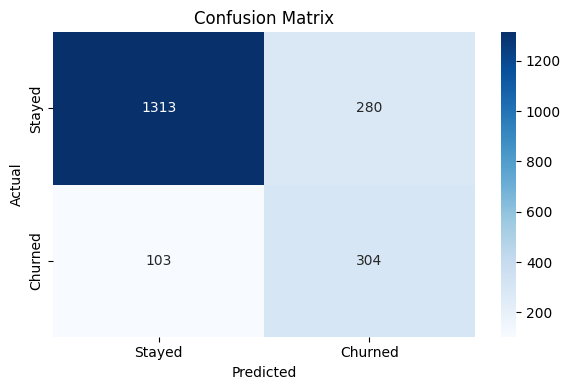

In [87]:
cm = confusion_matrix(y_test, y_pred_cost)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 17. 📈 ROC Curve & AUC Score

AUC-ROC measures the model's ability to distinguish churners from non-churners across all classification thresholds.
- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → Random guessing
- **AUC > 0.80** → Strong business-ready performance


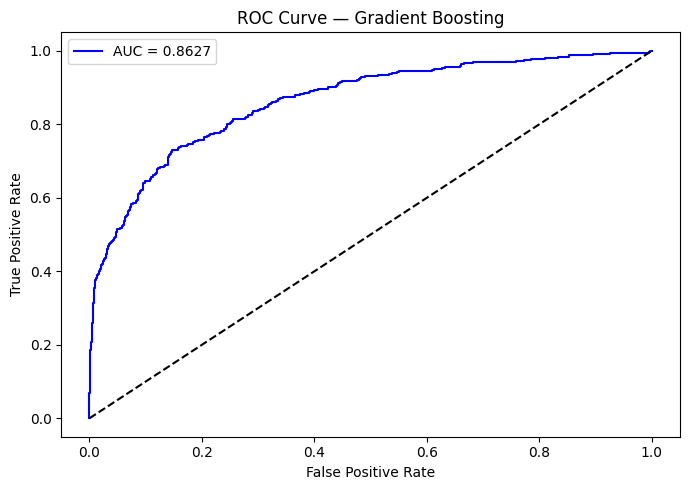

In [88]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model_pipeline.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='blue')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve — Gradient Boosting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

## 18. 💾 Model Export

Serializing the full pipeline (preprocessor + SMOTE + classifier) with  for deployment.
The exported pipeline accepts raw input (unscaled, uncoded) and handles all transformations internally.


In [89]:
import pickle
with open("../model/model_pipeline.pkl", "wb") as f:
    pickle.dump(model_pipeline, f)

In [90]:
num_features = ['Age', 'Balance', 'CreditScore', "EstimatedSalary","NumOfProducts","IsActiveMember"]
cat_features = ['Geography', 'Gender']
X  = num_features + cat_features 
X.append("Exited")
df = df[X]
df.to_csv("../data/Cleanind_data.csv")

---
## 19. ✅ Conclusion & Business Recommendations

### Model Performance Summary

| Metric | Score |
|---|---|
| **AUC-ROC** | See ROC curve above |
| **F1 Score** | Best among 9 models tested |
| **Algorithm** | Gradient Boosting |
| **Imbalance Handling** | SMOTE + class_weight |

### 💡 Business Recommendations

| Finding | Recommended Action |
|---|---|
| Inactive members churn 2× more | Launch re-engagement campaigns for IsActiveMember=0 |
| Germany churn rate ~32% | Dedicated Germany retention program |
| 4-product customers churn 100% | Cap cross-sell at 2 products; investigate 3–4 product dissatisfaction |
| High-balance customers are leaving | Assign relationship managers to high-balance segments |
| 0–1 year tenure = highest early churn | Strengthen onboarding and 90-day retention touchpoints |

### 🚀 Next Steps
- Hyperparameter tuning with GridSearchCV / Optuna
- SHAP explainability to validate feature importances
- Deploy pipeline as a REST API with FastAPI
- A/B test retention interventions on predicted high-risk customers

---
*Notebook by [Zain](https://github.com/Zainch032) | AI Engineering Student | Data Science & ML*
